# 06 — Pinned 7B/14B scale comparison

This phase validates a resumable 100-prompt Jacobian lens fit for the pinned Qwen2.5-14B revision, runs G1/G2/G3 at 14B, rebuilds 14B mean-difference directions from the frozen silent-cue manifest (never from 7B vectors), reruns the full frozen-clean-eligible two-hop analysis, and compares paired 7B/14B estimates. The preregistration gave no numeric threshold for ‘large’, ‘approximately zero’, or ‘sharpening’, so F7 reports estimates and bootstrap intervals without inventing a pass cutoff. Qwen-32B is skipped because its published weight files alone exceed the measured 100 GiB home quota.

In [1]:
import json
import os
from pathlib import Path

ROOT = Path('/home/jovyan/j-space-thoughts')
os.chdir(ROOT)
os.environ['PIP_USER'] = 'false'
os.environ['PYTHONNOUSERSITE'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
lens_path = ROOT / 'data/lenses/qwen2.5-14b_jlens_100prompts.pt'
lens_metadata_path = ROOT / 'data/lenses/qwen2.5-14b_jlens_100prompts.json'
from src.fit_qwen14b_lens import fit_qwen14b_lens, validate_completed_fit_artifacts

try:
    lens_fit_metadata = validate_completed_fit_artifacts(
        lens_path, lens_metadata_path, expected_n_prompts=100
    )
except ValueError as error:
    print('Final 14B lens artifacts are unavailable or invalid:', error)
    print('Starting/resuming the exclusively locked 100-prompt fit.')
    fit_qwen14b_lens(
        n_prompts=100, dim_batch=128, max_seq_len=128, checkpoint_every=10
    )
    lens_fit_metadata = validate_completed_fit_artifacts(
        lens_path, lens_metadata_path, expected_n_prompts=100
    )
else:
    print('Reusing validated completed pinned 14B lens:', lens_path)
fit_resume_mode = lens_fit_metadata.get('checkpoint_resume_mode', 'legacy_not_recorded')
print('Fit resume mode:', fit_resume_mode)
if fit_resume_mode == 'legacy_not_recorded':
    print('PROVENANCE LIMITATION: this completed fit predates the checkpoint sidecar; the known first 10 resumed contributions were not bound to prompt hashes in the legacy checkpoint. Preserve this caveat in the final report.')
print('14B lens GiB:', lens_path.stat().st_size / 2**30)

Reusing validated completed pinned 14B lens: /home/jovyan/j-space-thoughts/data/lenses/qwen2.5-14b_jlens_100prompts.pt
Fit resume mode: legacy_not_recorded
PROVENANCE LIMITATION: this completed fit predates the checkpoint sidecar; the known first 10 resumed contributions were not bound to prompt hashes in the legacy checkpoint. Preserve this caveat in the final report.
14B lens GiB: 1.2207105569541454


In [2]:
from src.scale_phase import run_scale_phase

scale_manifest = run_scale_phase(
    lens_path=lens_path,
    lens_metadata_path=lens_metadata_path,
    md_artifact_path=ROOT / 'data/directions/qwen2.5-14b_concept_vectors.pt',
    gates_7b_path=ROOT / 'data/raw/00_gates_qwen7b.json',
    md_7b_path=ROOT / 'data/raw/01_concept_vectors.json',
    twohop_7b_path=ROOT / 'data/raw/02_twohop_qwen2.5-7b.json',
    n_bootstrap=5000,
    n_permutations=5000,
    seed=1729,
)
scale = json.loads((ROOT / 'results/scale_comparison.json').read_text())
comparison = scale['comparison']

Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

G1 PASS: N=20, max mean KL=4.32e-08, max position KL=2.79e-07


G2 FAIL (directional subgate PASS): min spider rank=1, clean M=8.250, swap M=-0.250, swapped top='4'
G2 failure documented: Qwen/Qwen2.5-14B-Instruct does not reproduce the strict known-answer top-1 swap under the preregistered band. Downstream results at this scale are diagnostic.


14B MD FAIL: N=40 concepts, layer=31, retrieval top1=0.075, explicit top1=0.550, silent top10=0.062
14B MD validation failures: ['retrieval_top1_ci_above_chance', 'explicit_top5_at_least_0.80']


/opt/conda/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at ../aten/src/ATen/native/transformers/cuda/attention_backward.cu:102.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


TWO-HOP COMPUTED: eligible=226, rows=242/242, MD=16
TWO-HOP CORPUS PASS: N_clean_eligible=226 (required >=150); continuing either way.
Hypothesis verdict not auto-assigned; inspect reported estimates and CIs.


NB06 COMPUTED: 7B/14B comparison saved; 14B strict G2=FAIL, 14B MD=FAIL, 32B=SKIPPED_DISK_CONSTRAINT


In [3]:
import pandas as pd

display(pd.DataFrame([{
    'scale': tag,
    'G1': model['gates']['g1']['status'],
    'G2_strict': model['gates']['g2']['status'],
    'G2_directional': model['gates']['g2']['directional_subgate'],
    'G3': model['gates']['g3_attribution_validation']['status'],
    'attribution_reliable': model['gates']['g3_attribution_validation']['attribution_reliable'],
    'strict_workspace_usable': model['gates']['strict_workspace_usable'],
} for tag, model in comparison['models'].items()]))
print('14B lens provenance:', scale['qwen14b_lens_provenance'])
print('14B MD validation:', scale['qwen14b_md_validation']['status'])
print('32B:', scale['qwen32b'])

,scale,G1,G2_strict,G2_directional,G3,attribution_reliable,strict_workspace_usable
0,14B,PASS,FAIL,PASS,PASS,True,False
1,7B,PASS,FAIL,PASS,PASS,False,False


14B lens provenance: {'d_model': 5120, 'lens_bytes': 1310727980, 'lens_jacobian_dtypes': ['torch.float32'], 'lens_n_prompts': 100, 'lens_path': 'data/lenses/qwen2.5-14b_jlens_100prompts.pt', 'lens_sha256': '8676664be8d4beb30e0a7622869423b40bc1a2bae37b694878ac3ba9bdd37b29', 'lens_source_layers': [19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43], 'metadata_path': 'data/lenses/qwen2.5-14b_jlens_100prompts.json', 'metadata_sha256': 'f5ec292efad95d6aa0c0dd7d9778f66a21e3905650e46959545e0502db75fd96', 'model_id': 'Qwen/Qwen2.5-14B-Instruct', 'model_revision': 'cf98f3b3bbb457ad9e2bb7baf9a0125b6b88caa8', 'n_layers': 48, 'n_prompt_hashes': 100, 'selection': 'first 100 train records with >=600 characters', 'status': 'PASS', 'wikitext_revision': 'b08601e04326c79dfdd32d625aee71d232d685c3', 'workspace_layers': [19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43]}
14B MD validation: FAIL
32B: {'download

In [4]:
def estimated_value(statistic):
    return statistic.get('estimate') if statistic.get('status') == 'ESTIMATED' else None

def estimated_ci(statistic):
    if statistic.get('status') != 'ESTIMATED':
        return None
    return (statistic.get('ci_low'), statistic.get('ci_high'))

rows = []
for tag, model in comparison['models'].items():
    for method, result in model['methods'].items():
        partials = result.get('partial_correlations', {})
        read = partials.get('causal_read_given_write', {})
        write = partials.get('causal_write_given_read', {})
        attr = result.get('attribution_predicted_vs_real', {})
        damage = result.get('mean_ablation_positive_damage', {})
        rows.append({
            'scale': tag, 'direction': method, 'N': result.get('n', 0),
            'method status': result.get('status', 'UNKNOWN'),
            'partial causal~READ|WRITE': estimated_value(read),
            'READ CI': estimated_ci(read),
            'READ status': read.get('status', 'NOT_AVAILABLE'),
            'partial causal~WRITE|READ': estimated_value(write),
            'WRITE CI': estimated_ci(write),
            'WRITE status': write.get('status', 'NOT_AVAILABLE'),
            'mean ablation damage': estimated_value(damage),
            'attribution r': estimated_value(attr),
            'attribution status': attr.get('status', 'NOT_AVAILABLE'),
        })
display(pd.DataFrame(rows))
paired_rows = []
for method, result in comparison['paired_14b_minus_7b'].items():
    for quantity, estimate in result.get('delta_14b_minus_7b', {}).items():
        paired_rows.append({'direction': method, 'quantity': quantity, 'N_common': result.get('n_common', 0), 'delta_14B_minus_7B': estimated_value(estimate), 'ci_low': estimate.get('ci_low'), 'ci_high': estimate.get('ci_high'), 'status': estimate.get('status', 'NOT_AVAILABLE')})
display(pd.DataFrame(paired_rows))
print(comparison['p1_interpretation'])

,scale,direction,N,method status,partial causal~READ|WRITE,READ CI,READ status,partial causal~WRITE|READ,WRITE CI,WRITE status,mean ablation damage,attribution r,attribution status
0,14B,jlens_raw_wu_j,226,ESTIMATED,-0.164868,"(-0.29096180573862707, -0.03653910152510987)",ESTIMATED,-0.143635,"(-0.25311341621823746, -0.03019213238365344)",ESTIMATED,0.224318,0.514176,ESTIMATED
1,14B,mean_difference,16,ESTIMATED,0.137348,"(-0.35842852803278885, 0.574274147083833)",ESTIMATED,0.181303,"(-0.3372489904261657, 0.7026124397600609)",ESTIMATED,1.261719,0.805411,ESTIMATED
2,7B,jlens_raw_wu_j,155,ESTIMATED,0.429913,"(0.2654485763644903, 0.5649041887333488)",ESTIMATED,-0.107017,"(-0.24988688028670844, 0.04003091172499209)",ESTIMATED,3.098727,0.608368,ESTIMATED
3,7B,mean_difference,20,ESTIMATED,0.010130,"(-0.4985887384286478, 0.4595228336302168)",ESTIMATED,-0.429760,"(-0.7373939515752043, 0.11824018819479859)",ESTIMATED,1.301562,0.551594,ESTIMATED


,direction,quantity,N_common,delta_14B_minus_7B,ci_low,ci_high,status
0,jlens_raw_wu_j,attribution_predicted_vs_real_r,135,-0.105026,-0.273490,0.037118,ESTIMATED
1,jlens_raw_wu_j,mean_ablation_positive_damage,135,-3.416967,-4.059907,-2.751507,ESTIMATED
2,jlens_raw_wu_j,partial_causal_read_given_write,135,-0.610559,-0.821249,-0.362275,ESTIMATED
3,jlens_raw_wu_j,partial_causal_write_given_read,135,0.007969,-0.210192,0.228289,ESTIMATED
4,mean_difference,attribution_predicted_vs_real_r,14,0.169599,-0.264514,0.949631,ESTIMATED
5,mean_difference,mean_ablation_positive_damage,14,-0.100446,-1.877232,1.654018,ESTIMATED
6,mean_difference,partial_causal_read_given_write,14,0.010329,-0.547244,0.832646,ESTIMATED
7,mean_difference,partial_causal_write_given_read,14,0.291274,-0.426511,1.024880,ESTIMATED


{'direction_methods': ['jlens_raw_wu_j', 'mean_difference'], 'read_statistic': 'partial corr(CAUSAL, READ | WRITE)', 'reason': "The preregistration did not set a numerical threshold for a 'large' READ partial correlation, an 'approximately zero' WRITE partial correlation, or scale sharpening. Estimates, bootstrap CIs, and paired scale differences are reported without inventing a pass threshold.", 'status': 'DESCRIPTIVE_ESTIMATES_ONLY', 'write_statistic': 'partial corr(CAUSAL, WRITE | READ)'}


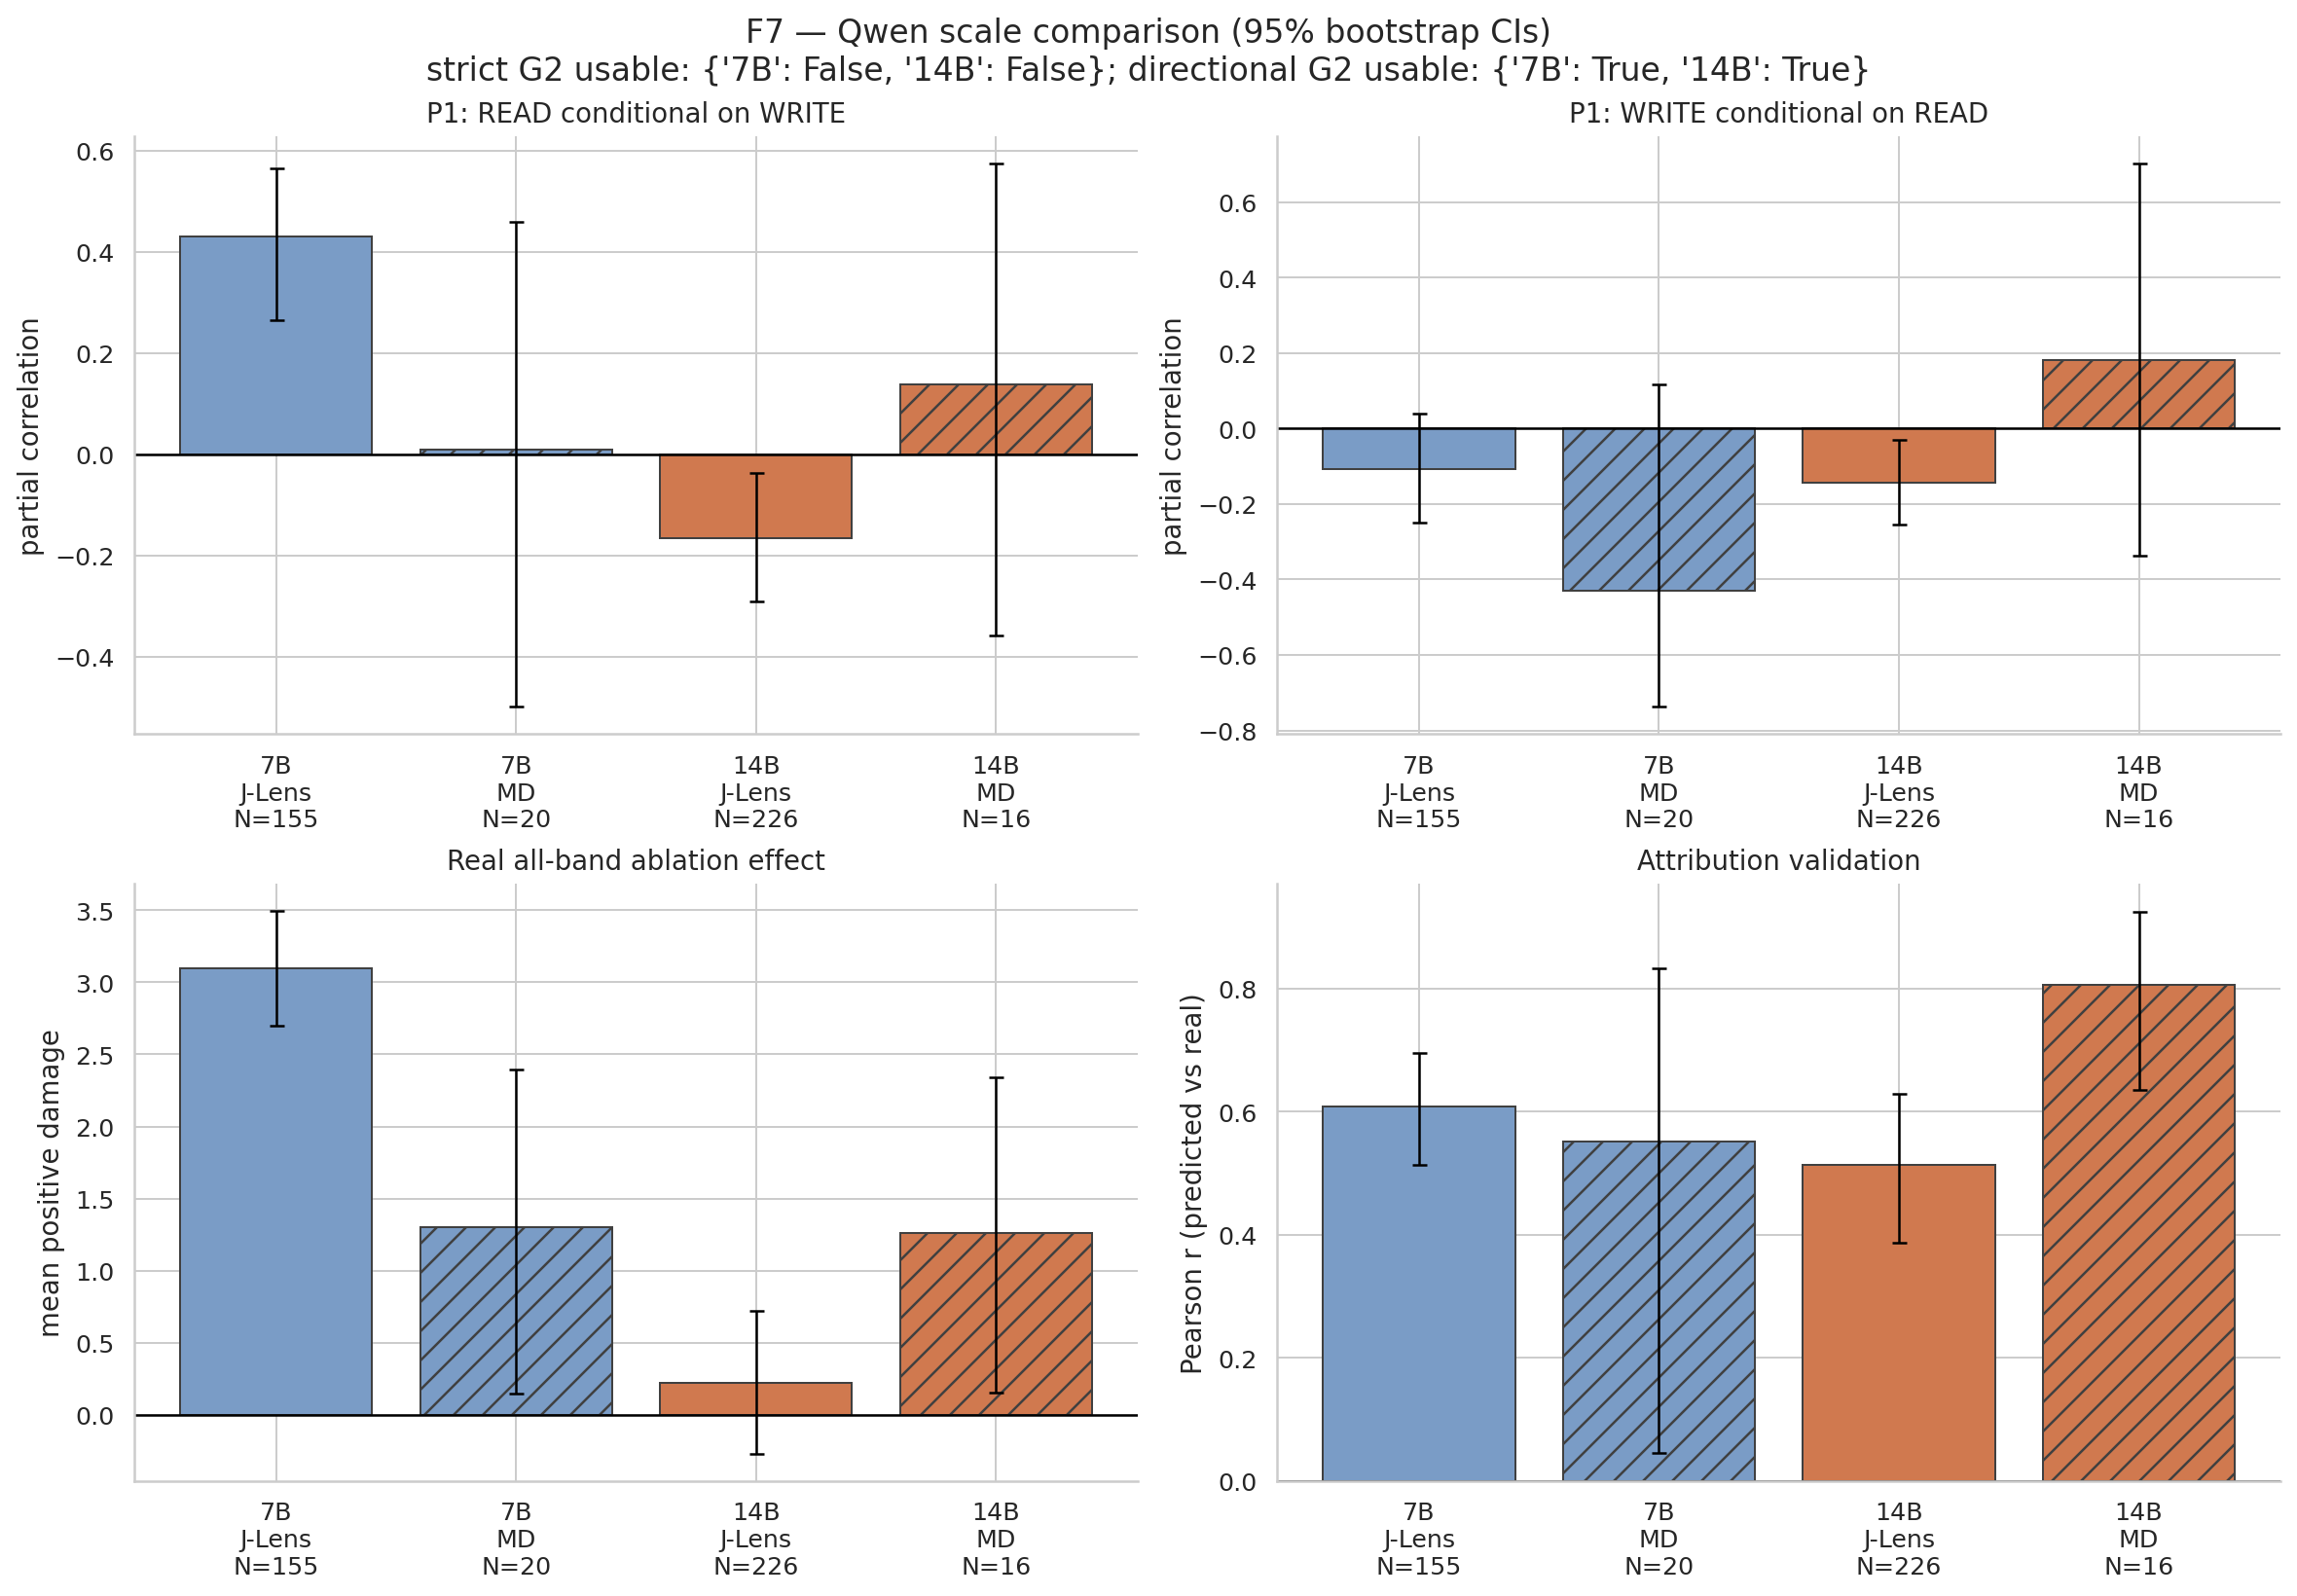

In [5]:
from IPython.display import Image, display

display(Image(filename=ROOT / scale['f7']))

In [6]:
print('PHASE 06 COMPUTED')
print('14B GATES', scale['qwen14b_gates'])
print('14B MD', scale['qwen14b_md_validation']['status'])
print('14B TWOHOP', scale['qwen14b_twohop'])
print('32B', scale['qwen32b']['status'])

PHASE 06 COMPUTED
14B GATES {'directional_workspace_usable': True, 'g1': {'max_prompt_mean_kl': 4.3200365951179265e-08, 'n': 20, 'status': 'PASS', 'threshold_mean_kl': 0.001}, 'g2': {'clean_metric': 8.25, 'directional_subgate': 'PASS', 'min_spider_jlens_rank': 1, 'status': 'FAIL', 'strict_criterion': 'clean top-1=8, spider J-Lens rank<=10, swapped top-1=6'}, 'g3_attribution_validation': {'attribution_reliable': True, 'correlation': {'ci_high': 0.6294951909643013, 'ci_level': 0.95, 'ci_low': 0.3862307462324187, 'estimate': 0.5141758777302808, 'n': 226, 'n_bootstrap': 5000, 'seed': 1733, 'status': 'ESTIMATED'}, 'meaning': 'Validation computed on the full frozen-clean-eligible two-hop core; reliability is a measured outcome, not a pass condition', 'n': 226, 'status': 'PASS'}, 'strict_workspace_usable': False}
14B MD FAIL
14B TWOHOP {'corpus_criterion': {'criterion': 'n_clean_eligible >= 150', 'n_clean_eligible': 226, 'raises_on_failure': False, 'status': 'PASS', 'threshold': 150}, 'sample